<a href="https://colab.research.google.com/github/Mukunda-art/Future_ML_03/blob/main/Resume_Candidate_Screening_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Candidate Ranking

   Resume ID  Match Score (%)  \
0       1219        69.845059   
1       1763        63.747117   
2       1143        56.849168   
9        927        52.008005   
4        244        51.698256   
6       1340        51.254266   
3       2154        49.845019   
8        281        42.859149   
5       1304        39.007013   
7        121        26.835312   

                                        Skills Found  \
0  [python, machine learning, sql, data analysis,...   
1      [python, machine learning, sql, scikit learn]   
2          [python, machine learning, data analysis]   
9                                 [machine learning]   
4                  [machine learning, communication]   
6                         [python, machine learning]   
3        [python, sql, deep learning, communication]   
8                            [python, deep learning]   
5                       [python, sql, data analysis]   
7                               [sql, communication]   


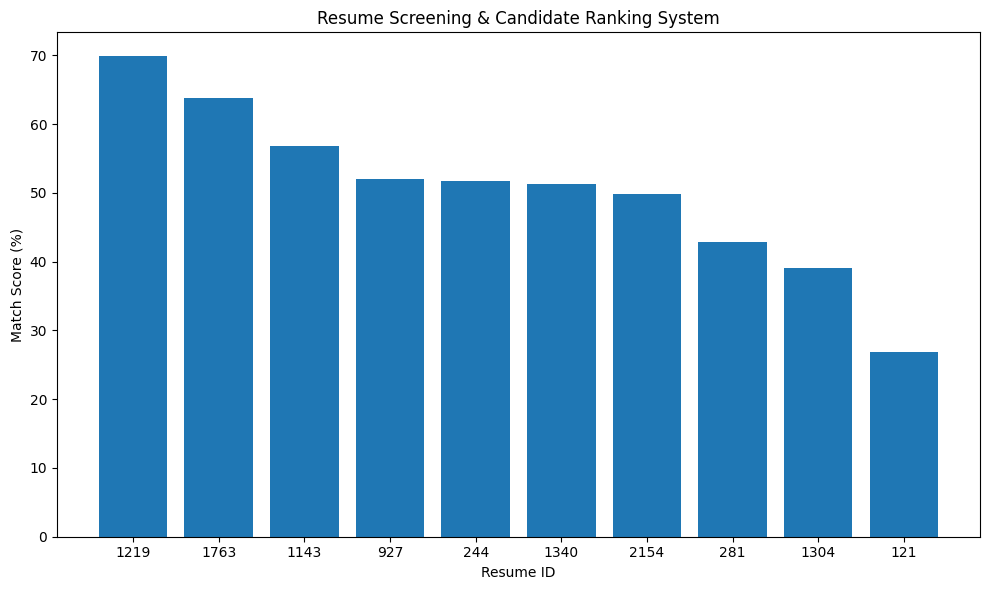


Output saved as candidate_ranking.csv


In [3]:
# =============================================
# RESUME / CANDIDATE SCREENING SYSTEM
# =============================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# ---------------------------------
# JOB DESCRIPTION
# ---------------------------------

job_description = """
Machine Learning Intern

Required Skills:
Python
Machine Learning
SQL
Data Analysis
Deep Learning
Scikit Learn
Communication
"""


# ---------------------------------
# SAMPLE RESUME DATASET
# ---------------------------------

resume_data = {

"Resume ID":[
1219,
1763,
1143,
2154,
244,
1304,
1340,
121,
281,
927
],

"Resume":[

"""
Python Machine Learning
SQL Data Analysis
Deep Learning
Communication
""",

"""
Python SQL
Scikit Learn
Machine Learning
""",

"""
Python
Data Analysis
Machine Learning
""",

"""
Deep Learning
Python SQL
Communication
""",

"""
Machine Learning
Communication
""",

"""
Python SQL
Data Analysis
""",

"""
Machine Learning
Python
""",

"""
SQL Communication
""",

"""
Python
Deep Learning
""",

"""
Machine Learning
"""
]

}


df = pd.DataFrame(resume_data)


# ---------------------------------
# CLEAN TEXT
# ---------------------------------

def clean_text(text):

    text = text.lower()

    text = re.sub(
        r'[^a-z ]',
        ' ',
        text
    )

    return text


df["clean_resume"] = (
    df["Resume"]
    .apply(clean_text)
)

job_clean = (
    clean_text(
        job_description
    )
)


# ---------------------------------
# TF-IDF
# ---------------------------------

documents = (
    [job_clean]
    +
    df["clean_resume"].tolist()
)

vectorizer = (
    TfidfVectorizer()
)

matrix = (
    vectorizer
    .fit_transform(documents)
)


# ---------------------------------
# MATCH SCORE
# ---------------------------------

scores = cosine_similarity(
    matrix[0:1],
    matrix[1:]
).flatten()


df["Match Score (%)"] = (
    scores
    *
    100
)


# ---------------------------------
# SKILL EXTRACTION
# ---------------------------------

skills = [
"python",
"machine learning",
"sql",
"data analysis",
"deep learning",
"communication",
"scikit learn"
]


def extract_skills(text):

    result = []

    for skill in skills:

        if skill in text:

            result.append(skill)

    return result


required = (
    extract_skills(
        job_clean
    )
)


df["Skills Found"] = (

df["clean_resume"]
.apply(
extract_skills
)

)


def missing(found):

    return list(
        set(required)
        -
        set(found)
    )


df["Missing Skills"] = (

df["Skills Found"]
.apply(
missing
)

)


# ---------------------------------
# RANK
# ---------------------------------

df = (
    df
    .sort_values(
        by="Match Score (%)",
        ascending=False
    )
)


print("\nCandidate Ranking\n")

print(

df[

[
"Resume ID",
"Match Score (%)",
"Skills Found",
"Missing Skills"
]

]

)


# ---------------------------------
# SAVE OUTPUT
# ---------------------------------

df.to_csv(
"candidate_ranking.csv",
index=False
)


# ---------------------------------
# VISUALIZATION
# ---------------------------------

plt.figure(
figsize=(10,6)
)

plt.bar(

df["Resume ID"]
.astype(str),

df["Match Score (%)"]

)

plt.title(
"Resume Screening & Candidate Ranking System"
)

plt.xlabel(
"Resume ID"
)

plt.ylabel(
"Match Score (%)"
)

plt.tight_layout()

plt.show()


print(
"\nOutput saved as candidate_ranking.csv"
)